In [482]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [483]:
adults_df = pd.read_csv('adult.csv', header=None)
adults_df.columns = ['age', 'workclass', 'sampling weight', 'education', 'education num', 'marital status', 'occupation',
                     'relationship', 'race', 'sex', 'capital gain', 'capital loss', 'hours per week', 'native country', 'income']
adults_df.head()

,age,workclass,sampling weight,education,education num,marital status,occupation,relationship,race,sex,capital gain,capital loss,hours per week,native country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Question 1: Clean your dataset to turn categorical values into numerical ones. One-hot encoding is likely the answer, but it depends on the dataset. Your data may have ordinal columns, for example where one-hot encoding is not as appropriate. 

In [484]:
print(adults_df['income'].unique())


adults_df['education'].value_counts()
adults_df.dtypes


[' <=50K' ' >50K']


age                 int64
workclass          object
sampling weight     int64
education          object
education num       int64
marital status     object
occupation         object
relationship       object
race               object
sex                object
capital gain        int64
capital loss        int64
hours per week      int64
native country     object
income             object
dtype: object

In [485]:
column_change = ['workclass', 'marital status', 'occupation', 'relationship', 'race', 'sex', 'native country', 'income']
for col in column_change:
    adults_df[col] = adults_df[col].astype(str).str.strip()

In [486]:
adults_df['workclass'] = adults_df['workclass'].astype(str).str.strip()
adults_df['marital status'] = adults_df['marital status'].astype(str).str.strip()


# workclass mapping
workclass_map = {'Private': 0, 'Self-emp-not-inc': 1, 'Local-gove': 2, 'State-gov': 3, 'Self-emp-inc': 4,'Federal-gov': 5, 'Without-pay': 6, 'Never-worked': 7}
adults_df['workclass'] = adults_df['workclass'].map(workclass_map)

# education drop, keep only education number
adults_df = adults_df.drop('education', axis=1)

# marital status mapping
marital_status_map = {'Never-married': 0, 'Married-civ-spouse': 1, 'Divorced': 2, 'Married-spouse-absent': 3, 'Separated': 4, 'Married-AF-spouse': 5, 'Widowed': 6}
adults_df['marital status'] = adults_df['marital status'].map(marital_status_map)

# occupation mapping
occupation_map = {'Adm-clerical': 0, 'Exec-managerial': 1, 'Handlers-cleaners': 2, 'Prof-specialty': 3, 'Other-service': 4, 'Sales': 5, 'Craft-repair': 6,
                  'Transport-moving': 7, 'Farming-fishing': 8, 'Machine-op-inspct': 9, 'Tech-support': 10, 'Protective-serv': 11, 'Armed-Forces': 12}
adults_df['occupation'] = adults_df['occupation'].map(occupation_map)

# relationship mapping
relationship_map = {'Not-in-family': 0, 'Husband': 1, 'Wife': 2,  'Own-child': 3, 'Unmarried': 4, 'Other-relative': 5}
adults_df['relationship'] = adults_df['relationship'].map(relationship_map)

# race mapping
race_map = {'White': 0, 'Black': 1, 'Asian-Pac-Islander': 2, 'Amer-Indian-Eskimo': 3, 'Other': 4}
adults_df['race'] = adults_df['race'].map(race_map)

# sex mapping
sex_map = {'Male': 0, 'Female': 1}
adults_df['sex'] = adults_df['sex'].map(sex_map)

#native country mapping
native_country_map = {'United-States': 1, 'Cuba': 2, 'Jamaica': 3, 'India': 4, '?': 5, 'Mexico': 6, 'South': 7,
                     'Puerto-Rico': 8, 'Honduras': 9, 'England': 10, 'Canada': 11, 'Germany': 12, 'Iran': 13,
                     'Philippines': 14, 'Italy': 15, 'Poland': 16, 'Columbia': 17, 'Cambodia': 18, 'Thailand': 19,
                     'Ecuador': 20, 'Laos': 21, 'Taiwan': 22, 'Haiti': 23, 'Portugal': 24, 'Dominican-Republic': 25,
                     'El-Salvador': 26, 'France': 27, 'Guatemala': 28, 'China': 29, 'Japan': 30, 'Yugoslavia': 31,
                     'Peru': 32, 'Outlying-US(Guam-USVI-etc)':33,'Scotland' :34,'Trinadad&Tobago' :35,
                     'Greece': 36, 'Nicaragua': 37, 'Vietnam': 38, 'Hong': 39, 'Ireland': 40, 'Hungary': 41,
                     'Holand-Netherlands': 42}
adults_df['native country'] = adults_df['native country'].map(native_country_map)

# income country mapping
income_mapping = {'<=50K': 0, '>50K': 1}
adults_df['income']  = adults_df['income'].map(income_mapping)

adults_df.head()

,age,workclass,sampling weight,education num,marital status,occupation,relationship,race,sex,capital gain,capital loss,hours per week,native country,income
0,39,3.0,77516,13,0,0.0,0,0,0,2174,0,40,1,0
1,50,1.0,83311,13,1,1.0,1,0,0,0,0,13,1,0
2,38,0.0,215646,9,2,2.0,0,0,0,0,0,40,1,0
3,53,0.0,234721,7,1,2.0,1,1,0,0,0,40,1,0
4,28,0.0,338409,13,1,3.0,2,1,1,0,0,40,2,0


Question 2: Perform univariate linear regression on the dataset. Select your variable to predict. How well did this model perform? Is this a good approach for this dataset? Why or why not? 


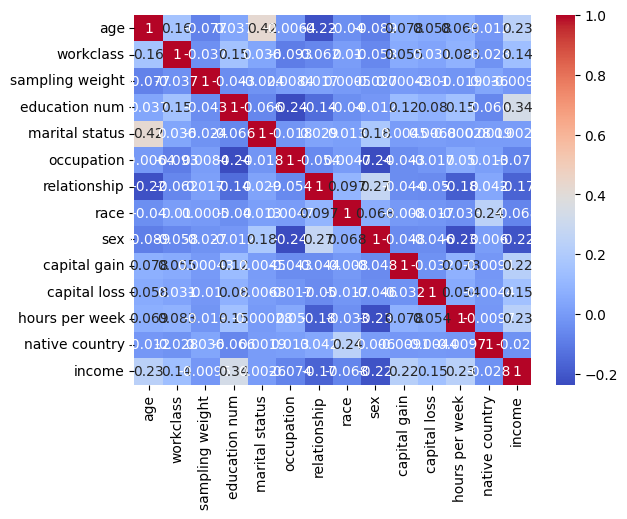

In [487]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

adults_new = adults_df.replace('?', np.nan)

y = adults_new['income']
X = adults_new.drop('income', axis=1)

X['occupation'] = X['occupation'].fillna(X['occupation'].median())
X['workclass'] = X['workclass'].fillna(X['workclass'].median())

X = pd.get_dummies(X)

correlation = adults_new.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.show()


In [488]:
y = adults_new['income']
X = adults_new[['age','marital status']]

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)
from sklearn.linear_model import LinearRegression

regression = LinearRegression()
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [489]:
y_pred = regression.predict(X_test)
y_pred
accuracy_score = regression.score(X_test, y_test)
accuracy_score


0.06417203377274505

For this model, I select two variables that have the highest correlation, which are age and marital status. This model perform not really well with pretty low accuracy score compared to others model I have done. From that, I don't think this is not a good approach for this dataset because income is a binary category instead of a continuous number. Also, univariate linear regression model can gives unrealistic predictions because it using only one variable and ignores the many other factors that might also influence income.

Question 3: Perform KNN on this dataset. As part of this, write a function that selects the optimal value of k. How well did this model perform?


In [490]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

adults_new = adults_df.replace('?', np.nan)

y = adults_new['income']
X = adults_new.drop('income', axis=1)

X['occupation'] = X['occupation'].fillna(X['occupation'].median())
X['workclass'] = X['workclass'].fillna(X['workclass'].median())

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.3, random_state=42)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
knn = KNeighborsClassifier(n_neighbors=26)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print(y_pred)
print(type(y_pred))


[0 0 0 ... 0 0 1]
<class 'numpy.ndarray'>


In [491]:
print(knn.score(X_test, y_test))

0.8416419285494933


I have tried different k variables from 10-30, I found the optimal k = 26, and KNN decrease if k larger than 26, as larger k can cause underfitting model. I think my model performed pretty good. And KNN is definitely a better model for predicting income because it is designed for classification problems and can consider multiple variables at once, unlike univariate linear regression.

Question 4: Work with your dataset to perform logistic regression. How well did this perform?


In [492]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from statsmodels.graphics.mosaicplot import mosaic
from sklearn.metrics import ConfusionMatrixDisplay

X = adults_df.drop('income', axis=1)
y = adults_df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)
X_train

array([[-0.48306519, -0.42795358, -1.44814967, ..., -0.21736176,
         0.36394747, -0.25525342],
       [ 0.32334184, -0.42795358, -0.83454879, ..., -0.21736176,
         0.36394747, -0.25525342],
       [-1.36278194,         nan, -0.64220378, ..., -0.21736176,
        -1.00510197, -0.25525342],
       ...,
       [ 1.20305859, -0.42795358, -1.02270456, ..., -0.21736176,
         1.16927066, -0.25525342],
       [-0.92292356, -0.42795358, -1.32642467, ..., -0.21736176,
         1.16927066, -0.25525342],
       [-1.43609167, -0.42795358,  2.13587088, ..., -0.21736176,
        -0.03871413, -0.25525342]], shape=(26048, 13))

In [ ]:
adults_new = adults_df.replace('?', np.nan)

y = adults_new['income']
X = adults_new.drop('income', axis=1)

X['occupation'] = X['occupation'].fillna(X['occupation'].median())
X['workclass'] = X['workclass'].fillna(X['workclass'].median())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

regression = LogisticRegression(random_state=42).fit(X_train, y_train)
y_predicted = regression.predict(X_test)
y_predicted

array([1, 0, 1, ..., 1, 0, 0], shape=(6513,))

In [494]:
regression.score(X_test, y_test)

0.8272685398433901

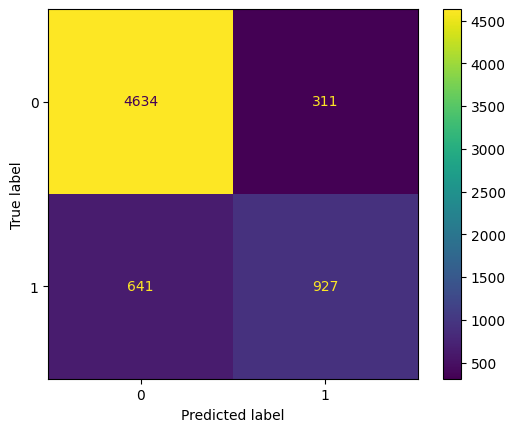

In [495]:
ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)


In [ ]:
def precision_and_recall(calc_type: str, tp: int, tn: int,
                          fp: int, fn: int) -> float:
    if calc_type == "precision":
        return tp / (tp + fp)  
    elif calc_type == "recall":
        return tp / (tp + fn)
    else:
        raise ValueError("something happened here. check your inputs")

print(precision_and_recall("precision", 927, 4634, 311, 641))  
print(precision_and_recall("recall", 927, 4634, 311, 641))     

0.7487883683360258
0.5911989795918368


I think my model perform pretty good with 82.73% accurate, but this is misleading because if the model just predicted ≤50K for everyone, it would still be 76% accurate and not really useful. However, it shows the unequal income distribution. The precision is 74.88%, which means that when it predicts >50K, it's right ~75% of the time. And recall is 59.12%, so the model can find around 6 out of 10 people who actually earn >50K. This model is better than univariate linear regression but might be slightly lower than KNN in terms of overall performance.


Question 5: Perform normalization on your dataset. Does it change the performance for 2-4? What is the best measure of performance for your dataset (accuracy or something else) and why?


In [499]:
knn_norm = KNeighborsClassifier(n_neighbors=29)
knn_norm.fit(X_train, y_train)
y_pred_knn = knn_norm.predict(X_test)
print("KNN Accuracy:", knn_norm.score(X_test, y_test))

regression_norm = LogisticRegression(random_state=30).fit(X_train, y_train)
regression_norm.fit(X_train, y_train)
y_pred_log = regression_norm.predict(X_test)
print("Logistic Accuracy:", regression_norm.score(X_test, y_test))

matrix_data = confusion_matrix(y_test, y_pred_knn)
tn, fp, fn, tp = matrix_data.ravel()
print("Data Precision:", precision_and_recall("precision",tp, tn, fp, fn))
print("Data Recall:", precision_and_recall("recall",tp, tn, fp, fn))


KNN Accuracy: 0.8478427759864886
Logistic Accuracy: 0.8272685398433901
Data Precision: 0.720734506503443
Data Recall: 0.6007653061224489


After applying normalization ,my KNN model accuracy improved slightly from 84.16% to 84.78%, while Logistic Regression remained unchanged at 82.73%. For KNN after normalization. I think in this case precision and recall are the best measures of performance for this dataset rather than accuracy. I have explained in the previous question that the accuracy score might be misleading. 

Precision (72%) tells us how reliable the model is when it predicts >50K, while recall (60%) tells us how many actual >50K earners the model correctly caught. And I believe that because we actually focus on predicting correctly for the minority class (>50K earners) in this case so having both metrics can give us clearer and more comparable overall performance.
